## 1. Install and import libraries

In [47]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [48]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/web-page-phishing.csv")

print("Dataset loaded successfully.")
print("Original dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Original dataset shape: (100077, 20)


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [49]:
# ============================================================
# 3. REMOVE EXACT DUPLICATE ROWS
# ============================================================

original_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

df_clean = df.drop_duplicates().copy()

clean_rows = df_clean.shape[0]
removed_rows = original_rows - clean_rows
removed_percentage = (removed_rows / original_rows) * 100

print("Original rows:", original_rows)
print("Duplicate rows removed:", removed_rows)
print("Duplicate percentage:", round(removed_percentage, 2), "%")
print("Cleaned dataset shape:", df_clean.shape)

Original rows: 100077
Duplicate rows removed: 78186
Duplicate percentage: 78.13 %
Cleaned dataset shape: (21891, 20)


In [50]:
# ============================================================
# 4. RESET INDEX AFTER CLEANING
# ============================================================

df_clean.reset_index(drop=True, inplace=True)

df_clean.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [51]:
# ============================================================
# 5. BASIC DATASET INFORMATION
# ============================================================

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nColumn names:")
print(df_clean.columns.tolist())

print("\nDataset information:")
df_clean.info()

Rows: 21891
Columns: 20

Column names:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection', 'phishing']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21891 entries, 0 to 21890
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url_length      21891 non-null  int64
 1   n_dots          21891 non-null  int64
 2   n_hypens        21891 non-null  int64
 3   n_underline     21891 non-null  int64
 4   n_slash         21891 non-null  int64
 5   n_questionmark  21891 non-null  int64
 6   n_equal         21891 non-null  int64
 7   n_at            21891 non-null  int64
 8   n_and           21891 non-null  int64
 9   n_exclamation   21891 non-null  int64
 10  n_space         21891 non-null  int64
 11  n_tilde         2

In [52]:
# ============================================================
# 6. COLUMN SUMMARY
# ============================================================

column_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.values,
    "Unique Values": df_clean.nunique().values,
    "Missing Values": df_clean.isnull().sum().values
})

column_summary

,Column,Data Type,Unique Values,Missing Values
0,url_length,int64,490,0
1,n_dots,int64,23,0
2,n_hypens,int64,33,0
3,n_underline,int64,22,0
4,n_slash,int64,25,0
5,n_questionmark,int64,6,0
6,n_equal,int64,22,0
7,n_at,int64,15,0
8,n_and,int64,21,0
9,n_exclamation,int64,10,0


In [53]:
# ============================================================
# 7. MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing Values": df_clean.isnull().sum().values,
    "Missing Percentage": (df_clean.isnull().sum().values / len(df_clean) * 100).round(2)
})

missing_summary

,Column,Missing Values,Missing Percentage
0,url_length,0,0.0
1,n_dots,0,0.0
2,n_hypens,0,0.0
3,n_underline,0,0.0
4,n_slash,0,0.0
5,n_questionmark,0,0.0
6,n_equal,0,0.0
7,n_at,0,0.0
8,n_and,0,0.0
9,n_exclamation,0,0.0


In [54]:
total_missing = df_clean.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


In [55]:
# ============================================================
# 8. TARGET VARIABLE ANALYSIS
# ============================================================

target_col = "phishing"

target_counts = df_clean[target_col].value_counts().sort_index()
target_percent = df_clean[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Meaning": ["Legitimate", "Phishing"],
    "Count": target_counts.values,
    "Percentage": target_percent.values.round(2)
})

target_summary

,Class,Meaning,Count,Percentage
0,0,Legitimate,6019,27.5
1,1,Phishing,15872,72.5


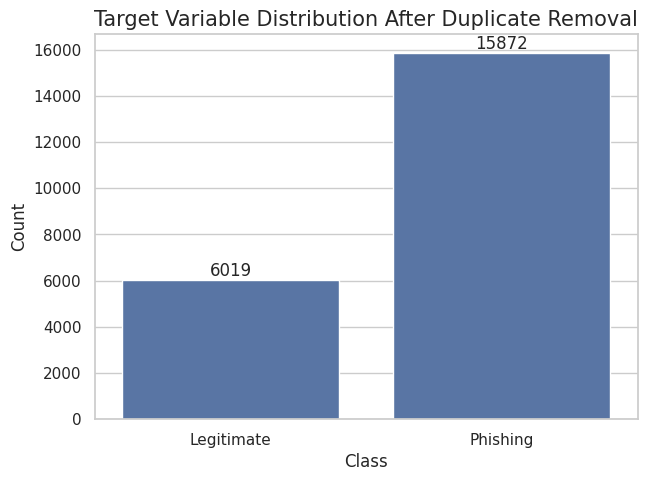

In [56]:
# ============================================================
# 9. TARGET DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df_clean, x=target_col)

plt.title("Target Variable Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Legitimate", "Phishing"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [57]:
# ============================================================
# 11. STATISTICAL SUMMARY
# ============================================================

summary_stats = df_clean.describe().T

summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats["unique_values"] = df_clean.nunique()
summary_stats["missing_values"] = df_clean.isnull().sum()

summary_stats

,count,mean,std,min,25%,50%,75%,max,range,unique_values,missing_values
url_length,21891.0,78.476086,77.361414,4.0,41.0,61.0,88.0,4165.0,4161.0,490,0
n_dots,21891.0,2.894066,2.161135,1.0,2.0,2.0,3.0,24.0,23.0,23,0
n_hypens,21891.0,1.308072,2.351815,0.0,0.0,1.0,2.0,43.0,43.0,33,0
n_underline,21891.0,0.482481,1.385397,0.0,0.0,0.0,0.0,21.0,21.0,22,0
n_slash,21891.0,2.569184,2.451018,0.0,0.0,2.0,4.0,44.0,44.0,25,0
n_questionmark,21891.0,0.083642,0.304815,0.0,0.0,0.0,0.0,9.0,9.0,6,0
n_equal,21891.0,0.710886,1.720661,0.0,0.0,0.0,1.0,23.0,23.0,22,0
n_at,21891.0,0.083824,0.554197,0.0,0.0,0.0,0.0,43.0,43.0,15,0
n_and,21891.0,0.492074,1.741748,0.0,0.0,0.0,0.0,26.0,26.0,21,0
n_exclamation,21891.0,0.009456,0.168437,0.0,0.0,0.0,0.0,10.0,10.0,10,0


In [58]:
# ============================================================
# 12. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

feature_cols = X.columns.tolist()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (21891, 19)
Target shape: (21891,)


In [59]:
# ============================================================
# 13. CLASS-WISE MEAN COMPARISON
# ============================================================

class_mean = df_clean.groupby(target_col).mean().T
class_mean.columns = ["Legitimate_Mean", "Phishing_Mean"]

class_mean["Difference"] = class_mean["Phishing_Mean"] - class_mean["Legitimate_Mean"]
class_mean["Abs_Difference"] = class_mean["Difference"].abs()

class_mean = class_mean.sort_values(by="Abs_Difference", ascending=False)

class_mean

,Legitimate_Mean,Phishing_Mean,Difference,Abs_Difference
url_length,52.288254,88.407069,36.118815,36.118815
n_slash,1.218641,3.081338,1.862697,1.862697
n_hypens,1.835022,1.108241,-0.726782,0.726782
n_equal,0.193886,0.906943,0.713057,0.713057
n_dots,2.399568,3.081590,0.682022,0.682022
n_and,0.094700,0.642767,0.548067,0.548067
n_redirection,0.673700,0.372669,-0.301031,0.301031
n_underline,0.371823,0.524446,0.152623,0.152623
n_at,0.000332,0.115486,0.115154,0.115154
n_percent,0.444924,0.361013,-0.083911,0.083911


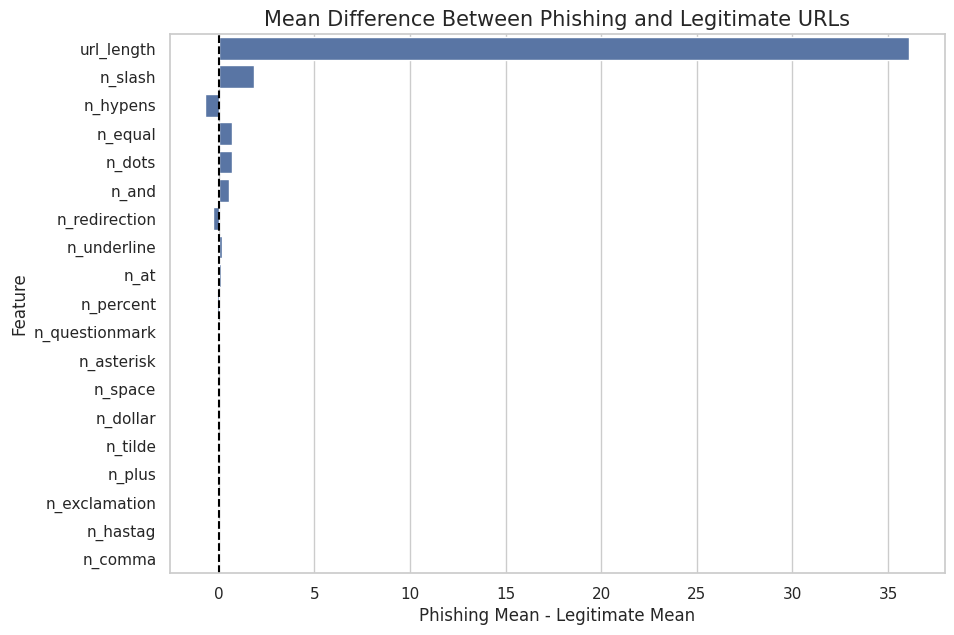

In [102]:
# ============================================================
# 14. CLASS-WISE MEAN DIFFERENCE PLOT
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=class_mean.reset_index(),
    x="Difference",
    y="index"
)

plt.title("Mean Difference Between Phishing and Legitimate URLs")
plt.xlabel("Phishing Mean - Legitimate Mean")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="--")

plt.show()

In [61]:
# ============================================================
# 15. CORRELATION WITH TARGET
# ============================================================

target_corr = (
    df_clean.corr()[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

target_corr_df = pd.DataFrame({
    "Feature": target_corr.index,
    "Correlation_With_Phishing": target_corr.values
})

target_corr_df

,Feature,Correlation_With_Phishing
0,n_slash,0.339327
1,url_length,0.208464
2,n_equal,0.185034
3,n_dots,0.140909
4,n_and,0.140498
5,n_questionmark,0.112592
6,n_at,0.092776
7,n_underline,0.049189
8,n_tilde,0.026570
9,n_dollar,0.025557


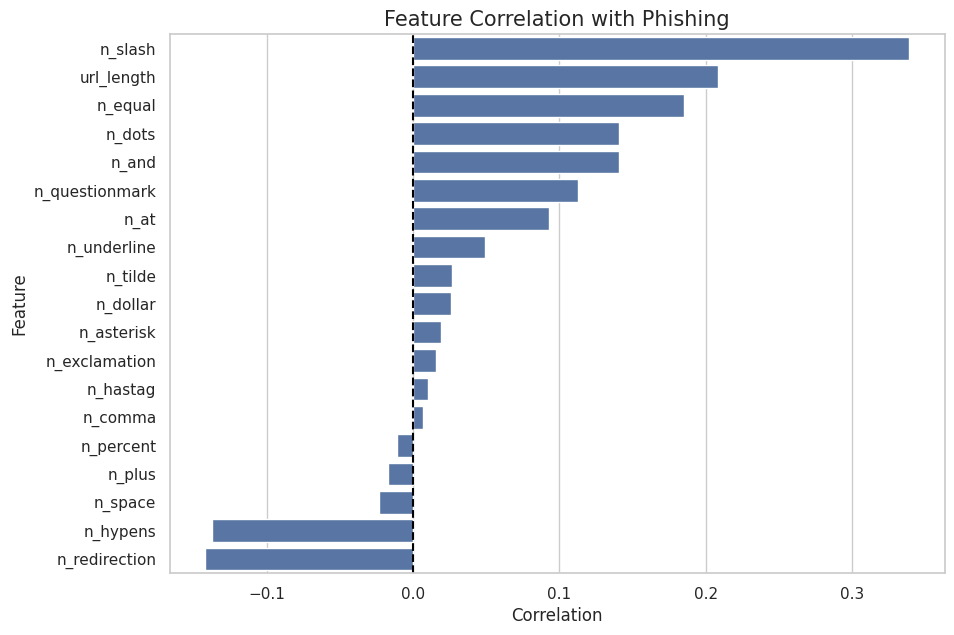

In [103]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=target_corr_df,
    x="Correlation_With_Phishing",
    y="Feature"
)

plt.title("Feature Correlation with Phishing")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="--")

plt.show()

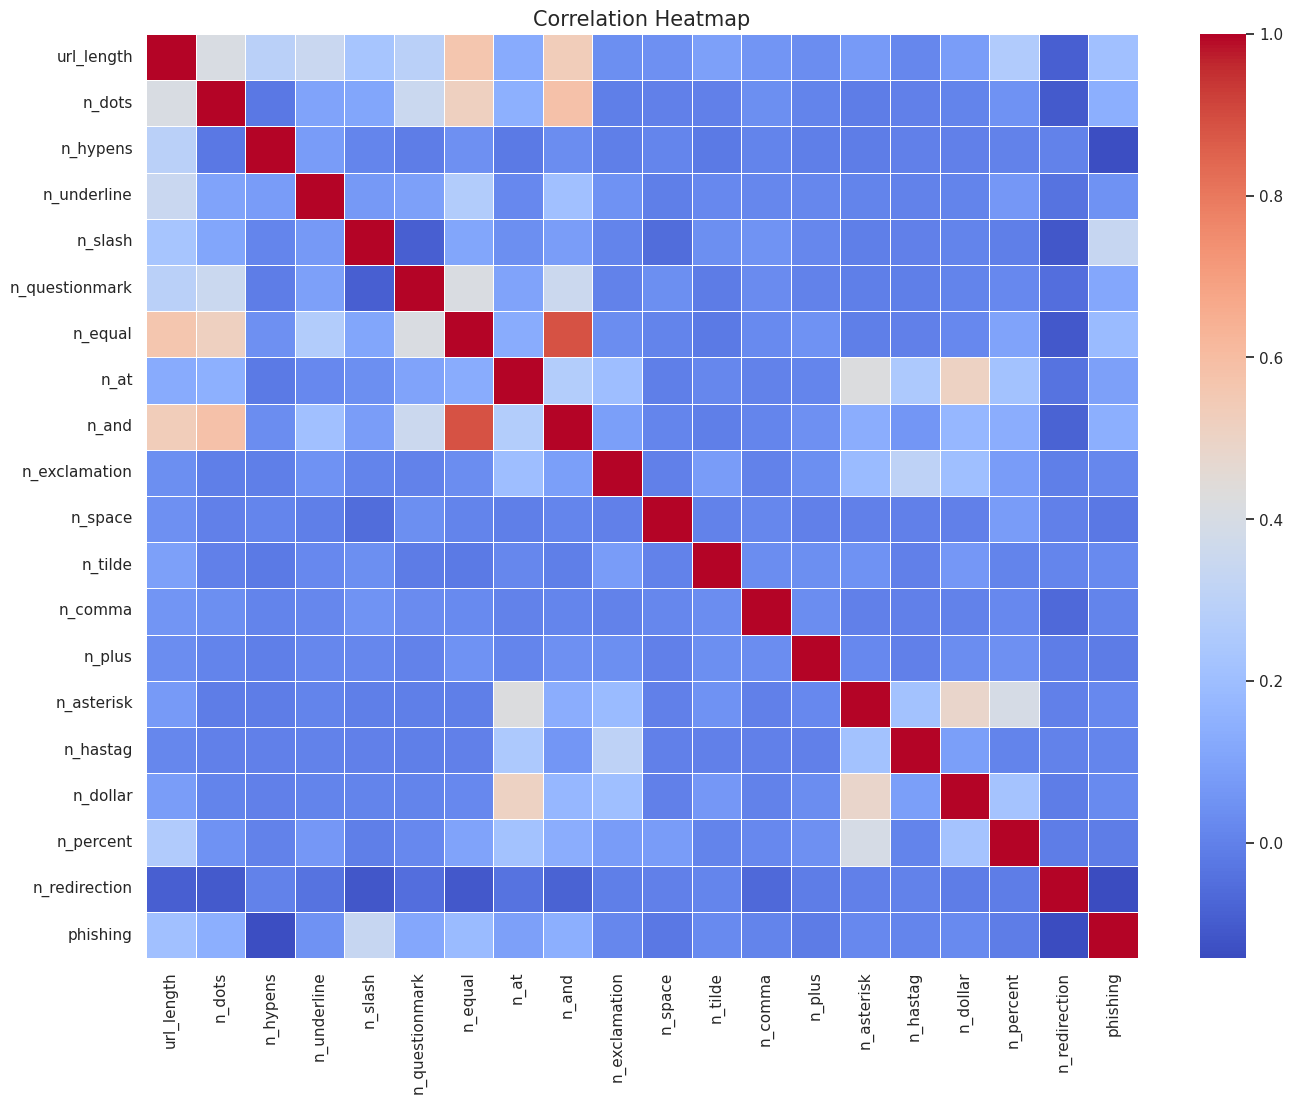

In [63]:
# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================

corr_matrix = df_clean.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

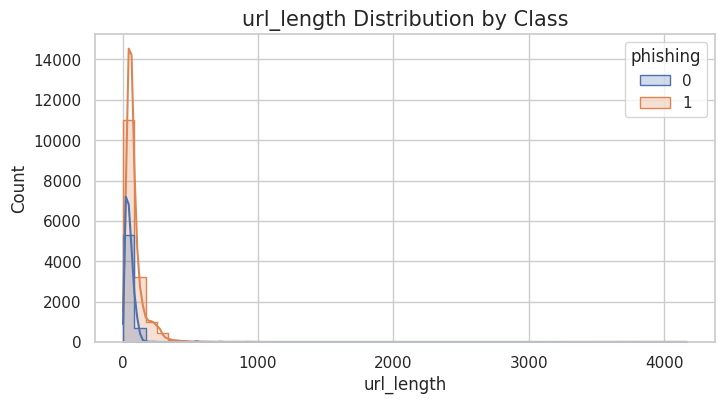

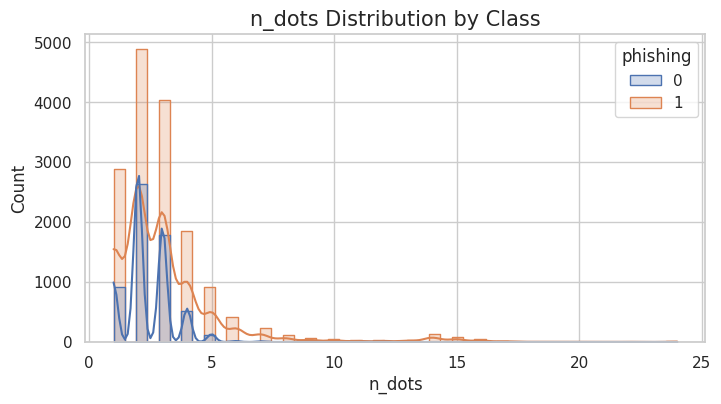

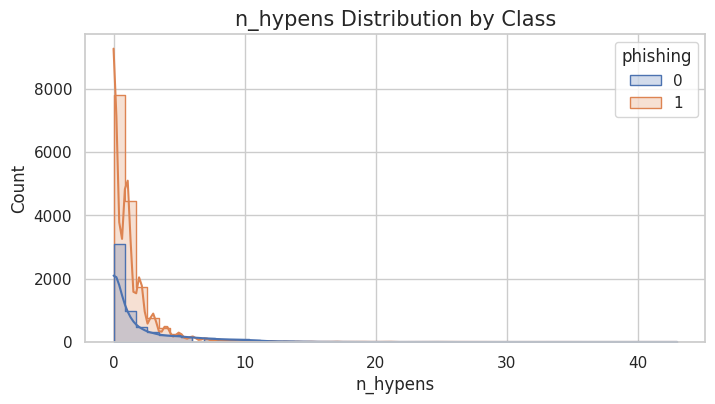

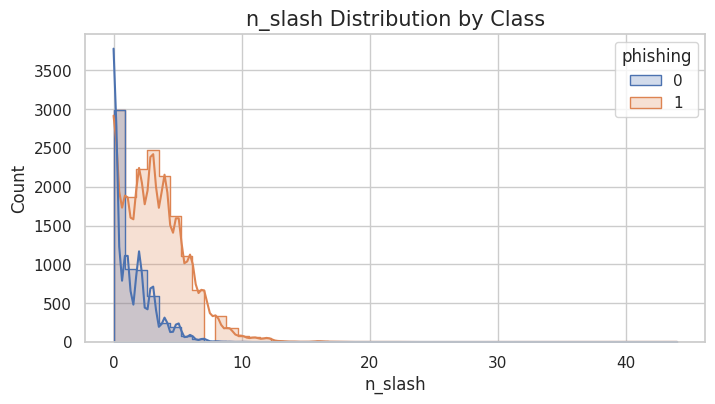

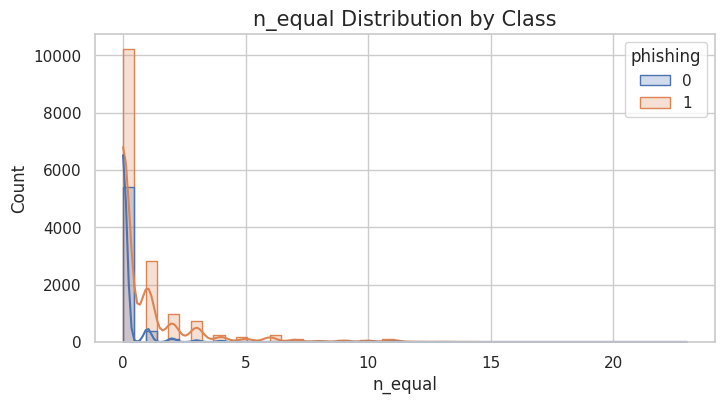

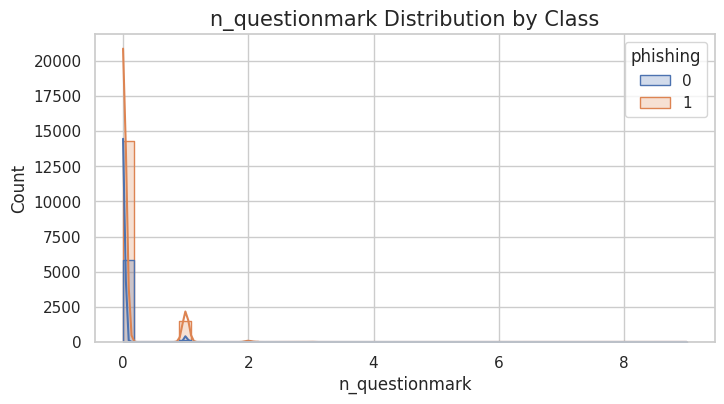

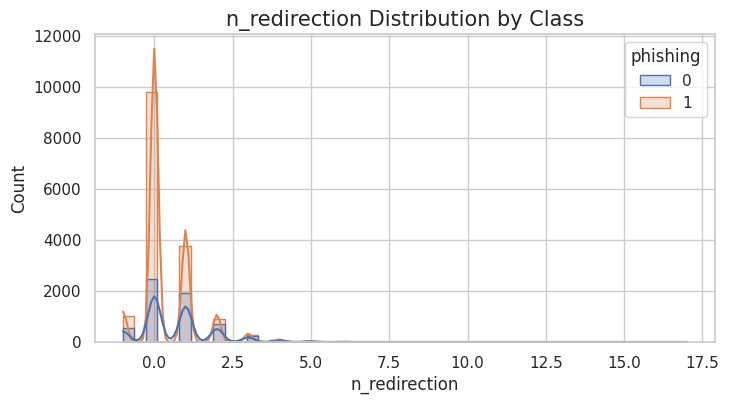

In [64]:
# ============================================================
# 17. IMPORTANT FEATURE DISTRIBUTIONS
# ============================================================

important_features = [
    "url_length",
    "n_dots",
    "n_hypens",
    "n_slash",
    "n_equal",
    "n_questionmark",
    "n_redirection"
]

for col in important_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=df_clean,
        x=col,
        hue=target_col,
        bins=50,
        kde=True,
        element="step"
    )
    plt.title(f"{col} Distribution by Class")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

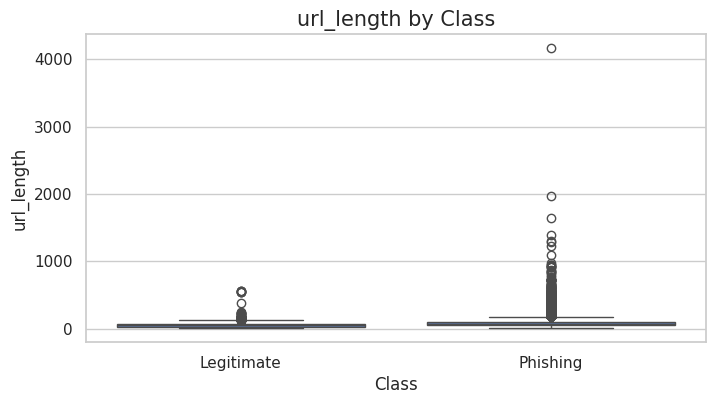

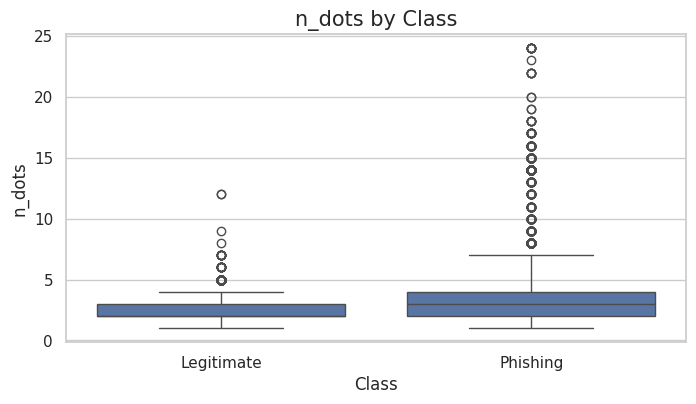

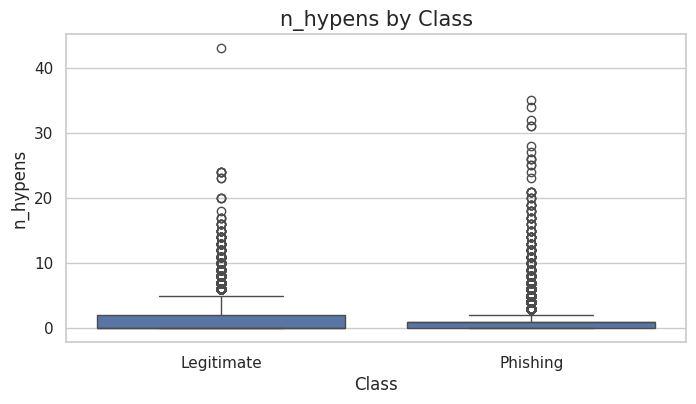

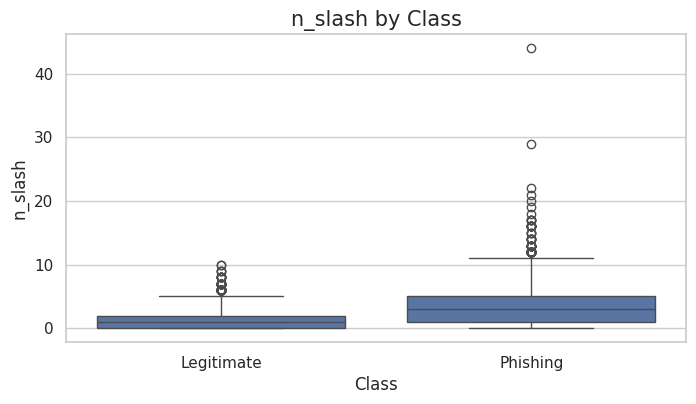

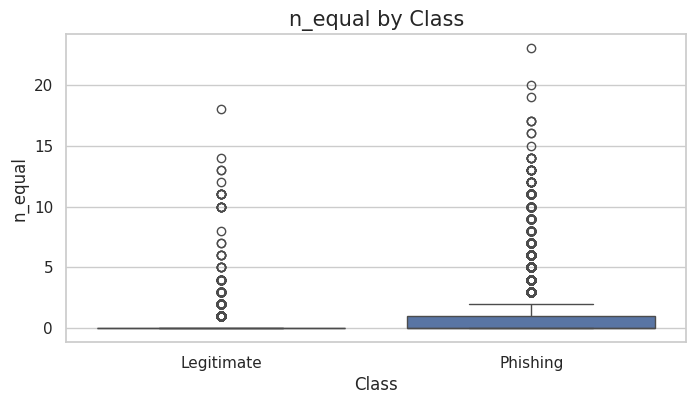

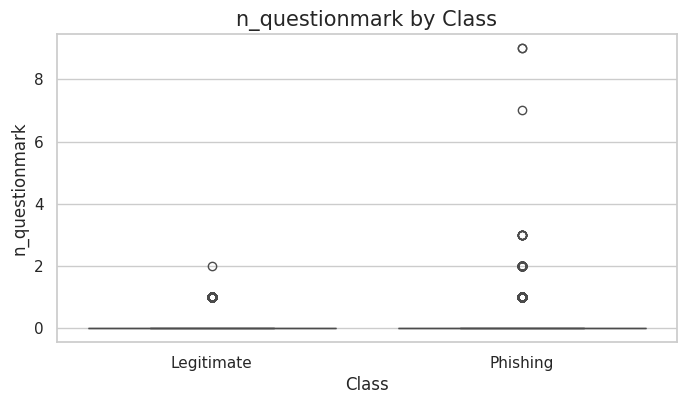

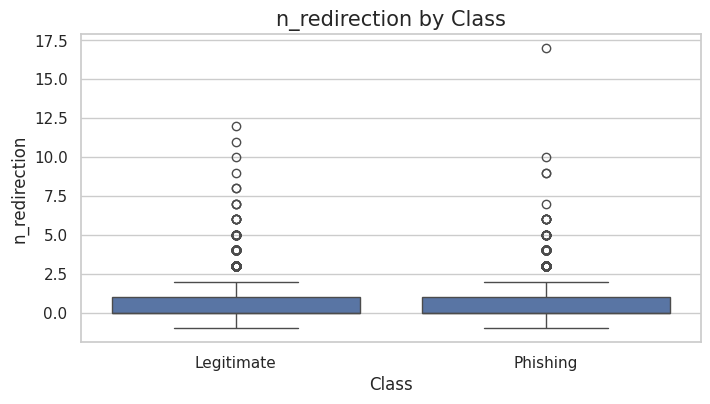

In [65]:
# ============================================================
# 18. BOXPLOT ANALYSIS
# ============================================================

for col in important_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=target_col, y=col)
    plt.title(f"{col} by Class")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Legitimate", "Phishing"])
    plt.show()

In [66]:
# ============================================================
# 19. ZERO VALUE ANALYSIS
# ============================================================

zero_summary = []

for col in feature_cols:
    zero_count = (df_clean[col] == 0).sum()
    zero_percentage = (zero_count / len(df_clean)) * 100

    zero_summary.append({
        "Feature": col,
        "Zero_Count": zero_count,
        "Zero_Percentage": round(zero_percentage, 2)
    })

zero_df = pd.DataFrame(zero_summary)
zero_df = zero_df.sort_values(by="Zero_Percentage", ascending=False)

zero_df

,Feature,Zero_Count,Zero_Percentage
15,n_hastag,21880,99.95
14,n_asterisk,21827,99.71
16,n_dollar,21827,99.71
13,n_plus,21792,99.55
12,n_comma,21789,99.53
9,n_exclamation,21752,99.37
10,n_space,21661,98.95
11,n_tilde,21660,98.94
7,n_at,20317,92.81
17,n_percent,20290,92.69


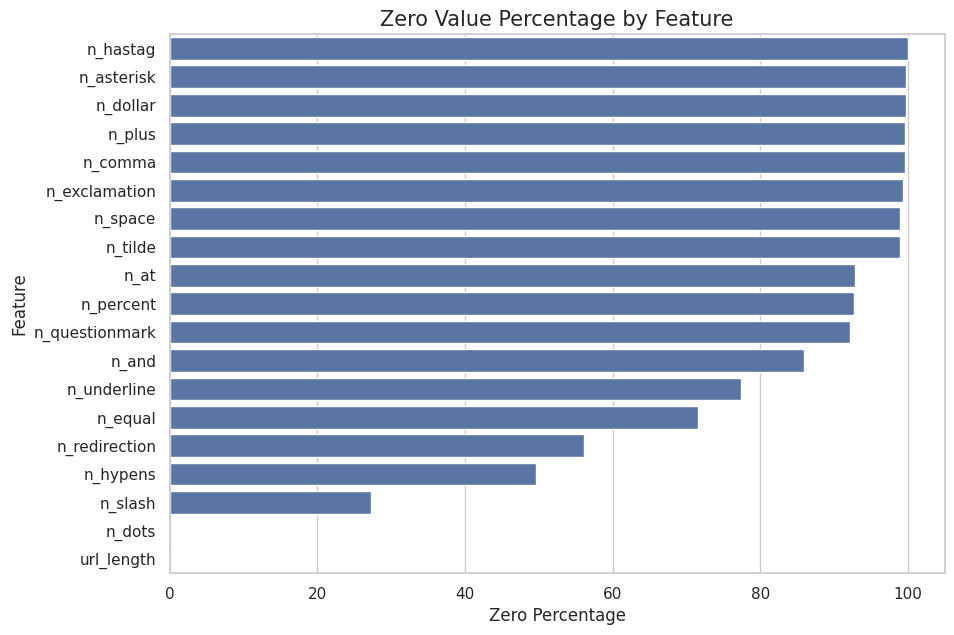

In [67]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=zero_df,
    x="Zero_Percentage",
    y="Feature"
)

plt.title("Zero Value Percentage by Feature")
plt.xlabel("Zero Percentage")
plt.ylabel("Feature")

plt.show()

In [68]:
# ============================================================
# 20. OUTLIER ANALYSIS USING IQR
# ============================================================

outlier_summary = []

for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": round((len(outliers) / len(df_clean)) * 100, 2),
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values(by="Outlier_Percentage", ascending=False)

outlier_df

,Feature,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
3,n_underline,4949,22.61,0.0,0.0
8,n_and,3075,14.05,0.0,0.0
1,n_dots,2359,10.78,0.5,4.5
6,n_equal,1958,8.94,-1.5,2.5
0,url_length,1858,8.49,-29.5,158.5
5,n_questionmark,1732,7.91,0.0,0.0
17,n_percent,1601,7.31,0.0,0.0
7,n_at,1574,7.19,0.0,0.0
2,n_hypens,1193,5.45,-3.0,5.0
18,n_redirection,756,3.45,-1.5,2.5


In [69]:
# ============================================================
# 21. SKEWNESS ANALYSIS
# ============================================================

skewness = df_clean[feature_cols].skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df

,Feature,Skewness
0,n_hastag,80.561885
1,n_asterisk,59.730196
2,n_at,47.226748
3,n_plus,45.562320
4,n_exclamation,36.113474
5,n_comma,34.053153
6,n_dollar,33.107631
7,n_space,29.628716
8,n_percent,24.660832
9,n_tilde,17.842145


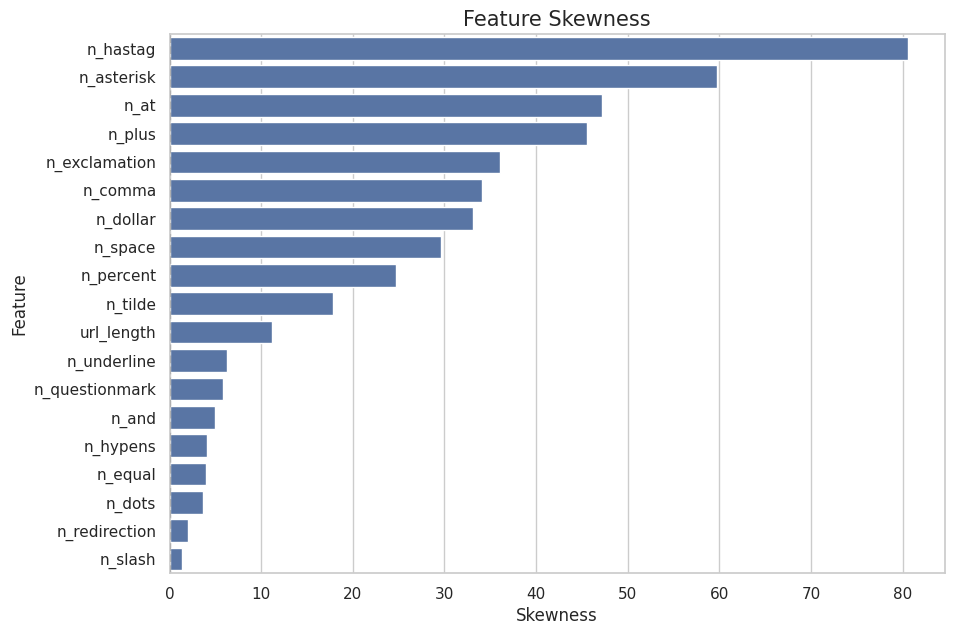

In [70]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=skewness_df,
    x="Skewness",
    y="Feature"
)

plt.title("Feature Skewness")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="--")

plt.show()

In [71]:
# ============================================================
# 22. FEATURE ENGINEERING FOR EDA
# ============================================================

symbol_features = [
    "n_dots", "n_hypens", "n_underline", "n_slash",
    "n_questionmark", "n_equal", "n_at", "n_and",
    "n_exclamation", "n_space", "n_tilde", "n_comma",
    "n_plus", "n_asterisk", "n_hastag", "n_dollar",
    "n_percent"
]

df_clean["total_special_chars"] = df_clean[symbol_features].sum(axis=1)

df_clean["url_complexity_score"] = (
    df_clean["url_length"] +
    df_clean["total_special_chars"] +
    df_clean["n_redirection"] * 5
)

df_clean[["total_special_chars", "url_complexity_score", target_col]].head()

,total_special_chars,url_complexity_score,phishing
0,3,40,0
1,1,83,1
2,13,144,1
3,2,25,0
4,4,64,0


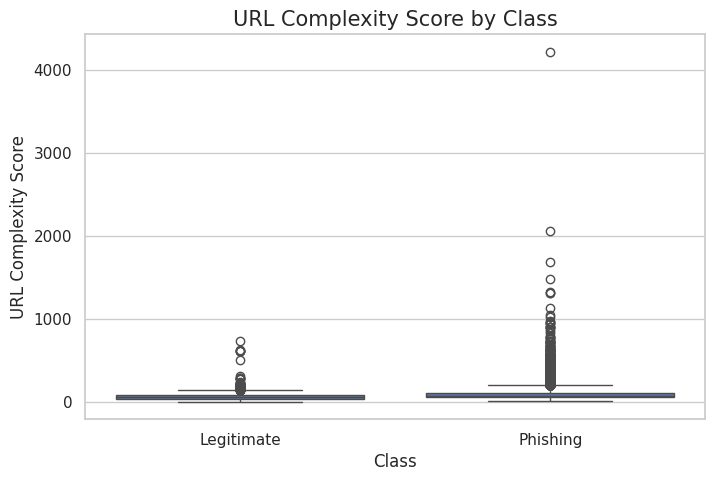

In [72]:
# ============================================================
# 23. URL COMPLEXITY SCORE BY CLASS
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x=target_col,
    y="url_complexity_score"
)

plt.title("URL Complexity Score by Class")
plt.xlabel("Class")
plt.ylabel("URL Complexity Score")
plt.xticks([0, 1], ["Legitimate", "Phishing"])

plt.show()

In [73]:
# ============================================================
# 24. FINAL EDA SUMMARY TABLE
# ============================================================

eda_summary = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Rows After Duplicate Removal",
        "Rows Removed",
        "Duplicate Percentage",
        "Total Columns",
        "Input Features",
        "Target Column",
        "Missing Values",
        "Legitimate Count",
        "Phishing Count",
        "Legitimate Percentage",
        "Phishing Percentage"
    ],
    "Value": [
        original_rows,
        df_clean.shape[0],
        removed_rows,
        round(removed_percentage, 2),
        df_clean.shape[1],
        len(feature_cols),
        target_col,
        df_clean.isnull().sum().sum(),
        target_counts.loc[0],
        target_counts.loc[1],
        round(target_percent.loc[0], 2),
        round(target_percent.loc[1], 2)
    ]
})

eda_summary

,Metric,Value
0,Original Rows,100077
1,Rows After Duplicate Removal,21891
2,Rows Removed,78186
3,Duplicate Percentage,78.13
4,Total Columns,22
5,Input Features,19
6,Target Column,phishing
7,Missing Values,0
8,Legitimate Count,6019
9,Phishing Count,15872


In [74]:
df_clean = df.drop_duplicates().copy()

In [87]:
# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

target_col = "phishing"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True) * 100)

Feature shape: (21891, 19)
Target shape: (21891,)

Target distribution:
phishing
1    72.504682
0    27.495318
Name: proportion, dtype: float64


In [88]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (17512, 19)
Testing feature shape: (4379, 19)
Training target shape: (17512,)
Testing target shape: (4379,)


In [89]:
# ============================================================
# 6. DEVELOP GRADIENT BOOSTING MODEL
# ============================================================

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [90]:
# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================

y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [91]:
# ============================================================
# 8. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Gradient Boosting Model Performance")
print("=" * 45)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Gradient Boosting Model Performance
Accuracy : 0.8155
Precision: 0.8377
Recall   : 0.9247
F1 Score : 0.879
ROC-AUC  : 0.8718


In [92]:
# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Phishing"]
))

              precision    recall  f1-score   support

  Legitimate       0.73      0.53      0.61      1204
    Phishing       0.84      0.92      0.88      3175

    accuracy                           0.82      4379
   macro avg       0.78      0.73      0.75      4379
weighted avg       0.81      0.82      0.81      4379



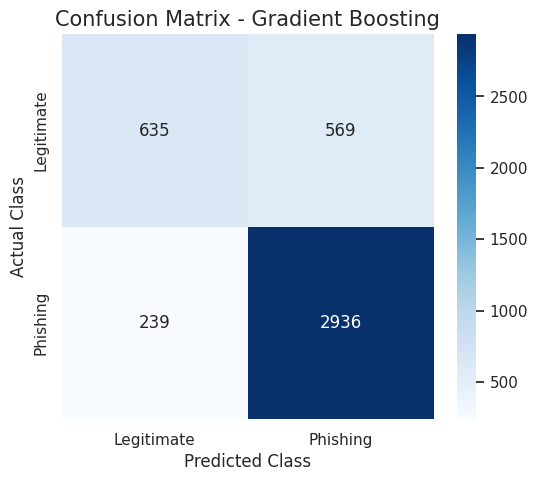

In [93]:
# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

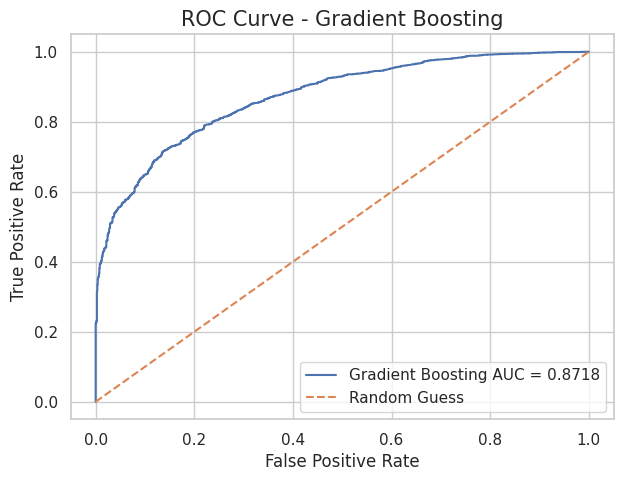

In [94]:
# ============================================================
# 11. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Gradient Boosting AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve - Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [95]:
# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,n_slash,0.343373
0,url_length,0.225758
2,n_hypens,0.145335
6,n_equal,0.084042
1,n_dots,0.074038
3,n_underline,0.029287
18,n_redirection,0.027599
7,n_at,0.022812
5,n_questionmark,0.018729
17,n_percent,0.013536


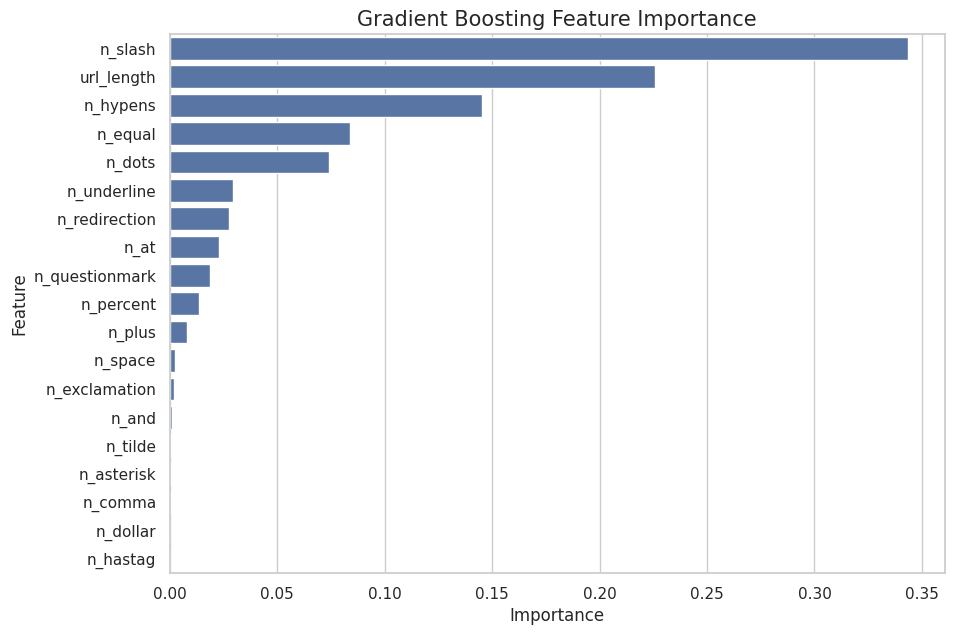

In [96]:
# ============================================================
# 13. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [97]:
# ============================================================
# 14. SAVE FINAL MODEL
# ============================================================

joblib.dump(gb_model, "gradient_boosting_phishing_model.pkl")

print("Gradient Boosting model saved successfully.")

Gradient Boosting model saved successfully.


In [98]:
# ============================================================
# 15. LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load("gradient_boosting_phishing_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [99]:
# ============================================================
# 16. PREDICT ONE SAMPLE
# ============================================================

sample = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample)
sample_probability = loaded_model.predict_proba(sample)[:, 1]

print("Prediction:", sample_prediction[0])
print("Phishing probability:", round(sample_probability[0], 4))

if sample_prediction[0] == 1:
    print("Result: Phishing URL")
else:
    print("Result: Legitimate URL")

Prediction: 1
Phishing probability: 0.8248
Result: Phishing URL
